In [1]:
# showing table schema and creating path variables
import duckdb

# PARQUET FILES ARE FROM https://huggingface.co/datasets/SII-WANGZJ/Polymarket_data BIG THANK YOU FOR ALL THE DATA
# Note I made a new User file to add if a users trade won or not in DBshenanigans.py to make everything easier for training (the win rate is about 49.91%)

tradesPQ = 'X:/PolymarketData/trades.parquet'
marketPQ = 'X:/PolymarketData/markets.parquet'
usersPQ = 'X:/PolymarketData/Users2.parquet'
print("User Schema:")
print(duckdb.query(f" SELECT * FROM '{usersPQ}' LIMIT 1"))
print("Trade Schema:")
print(duckdb.query(f" SELECT * FROM '{tradesPQ}' LIMIT 1"))
print("Market Schema:")
print(duckdb.query(f" SELECT * FROM '{marketPQ}' LIMIT 1"))

User Schema:
┌────────────┬──────────────┬──────────────────────────────────────────────────────────────────┬───────────┬────────────────────────────────────────────┬─────────┬───────────┬────────────┬──────────────┬────────┬───────────┬────────────────────────────────────────────────────────────────────┬──────────┬──────────────┬─────────┐
│ timestamp  │ block_number │                         transaction_hash                         │ log_index │                  address                   │  role   │ direction │ usd_amount │ token_amount │ price  │ market_id │                            condition_id                            │ event_id │ nonusdc_side │   won   │
│   uint64   │    uint64    │                             varchar                              │  uint32   │                  varchar                   │ varchar │  varchar  │   double   │    double    │ double │  varchar  │                              varchar                               │ varchar  │   varchar    │ boolean

In [2]:
userlist = duckdb.query(f"SELECT address, COUNT(*) AS nTrades, AVG(CAST(won AS INTEGER)) AS win_rate, AVG(usd_amount) as avg_spent, SUM(usd_amount) as total_spent FROM '{usersPQ}' GROUP BY address HAVING COUNT(*) > 20")
print(userlist)

┌────────────────────────────────────────────┬─────────┬─────────────────────┬────────────────────┬────────────────────┐
│                  address                   │ nTrades │      win_rate       │     avg_spent      │    total_spent     │
│                  varchar                   │  int64  │       double        │       double       │       double       │
├────────────────────────────────────────────┼─────────┼─────────────────────┼────────────────────┼────────────────────┤
│ 0xc4cd61d921d8ea3ac75d71bf87b26523954e7d22 │     164 │  0.9329268292682927 │ 188.13518292073172 │       30854.169999 │
│ 0x296bd652f74deac6a8bd9bcb04265f3a65fd2cf2 │    2581 │ 0.47849670670282834 │ 128.89540874893424 │  332679.0499809993 │
│ 0xc68cb65c976eb7c39930dc762d8b0f41b1ea40e4 │      61 │  0.5081967213114754 │  11.11459013114754 │         677.989998 │
│ 0xa79af3bab636f41f1f7bd1c568857dbdf4650beb │      25 │                0.32 │             3.2352 │              80.88 │
│ 0x79d78ddcdf86d0056132fdfc7d1f

In [3]:
userdf = userlist.to_df()
print(userdf)

                                            address  nTrades  win_rate  \
0        0x7c61fa02f1fdb9bcf5e5c904ca6a724abc0315c0     1085  0.695853   
1        0x67a3111a4c20bfad5dd1f50f46453420f6462223      190  0.489474   
2        0x5a54a5c4b541969601e01aa69c7717bd534350fd      260  0.496154   
3        0x766c611a18d7db02a1f8d946bc59f02fd24512b3      140  0.200000   
4        0xa720526063e734e2ee2dff2e1adf733061d8973f       52  0.134615   
...                                             ...      ...       ...   
1412126  0xafb45306080004620e5e51fcf201c19e3b7bac91       28  0.071429   
1412127  0x7b9e402d5eed04d7ba2ebf31af7804d7f3717479       24  0.041667   
1412128  0x5b1eff51993a0169c651bf09674a7fd328e58dc0       40  1.000000   
1412129  0x2700415227ed3ef7382e1e7ae058a51beb18f8d7       43  0.953488   
1412130  0x47be5c9aeab11a3f0daadca0ba49b0866bb1a537       39  1.000000   

          avg_spent    total_spent  
0        214.671982  232919.100962  
1        158.140684   30046.730000  


          avg_spent  nTrades    total_spent  win_rate
0        214.671982     1085  232919.100962  0.695853
1        158.140684      190   30046.730000  0.489474
2         44.881077      260   11669.080000  0.496154
3         83.238429      140   11653.380000  0.200000
4         21.331538       52    1109.240000  0.134615
...             ...      ...            ...       ...
1412126    2.892857       28      81.000000  0.071429
1412127   58.887917       24    1413.310000  0.041667
1412128    4.605500       40     184.220000  1.000000
1412129   16.470698       43     708.240000  0.953488
1412130    4.823077       39     188.100000  1.000000

[1412131 rows x 4 columns]


<Axes: >

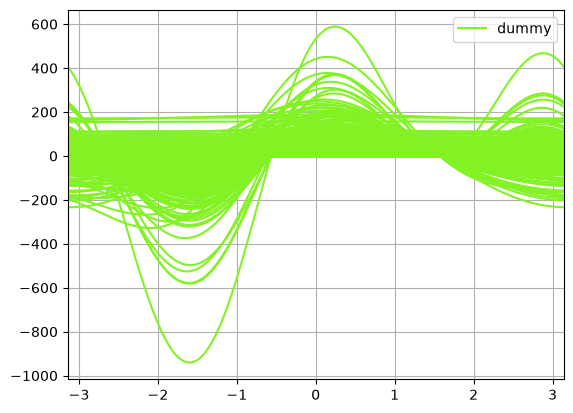

In [4]:
import pandas as pd
userdf["dummy"] = "dummy"
keepcolumn = ["address","dummy"]
rest = userdf.columns.difference(keepcolumn)
print(userdf[rest])
userdf[rest] = (userdf[rest] - userdf[rest].mean())/userdf[rest].std()
pd.plotting.andrews_curves(userdf[userdf.columns.difference(["address"])], 'dummy')